# ALSRS — Flexible classification from the regression model

The model is **regression**: it predicts the continuous deficit, and the metric
that matters is MAE/RMSE. The class assignment is a **post-hoc, flexible step**:
because we have continuous predictions, we can re-group them into 4, 3 or 2
classes **without retraining**.

This is exactly why regression was the right choice: the model is as accurate as
possible on the magnitude, and the class granularity is a separate decision we
can change per need.

## The schemes compared here

| scheme | thresholds | classes |
|---|---|---|
| 4 classes | 15 / 30 / 50 | LOW, MEDIUM, HIGH, NOT_SUITABLE |
| 3 classes | 15 / 50 | LOW, MODERATE, SEVERE |
| 2 classes @20 | 20 | MODERATE, SEVERE |
| 2 classes @30 | 30 | MODERATE, SEVERE |

The key question: **do we gain accuracy by using fewer, wider classes?**



In [1]:
# -----------------------------------------------------------------------------
# 1. Imports
# -----------------------------------------------------------------------------
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, confusion_matrix

print("pandas", pd.__version__, "| numpy", np.__version__)



pandas 2.3.3 | numpy 2.2.6


In [3]:
# -----------------------------------------------------------------------------
# 2. Dataset + configuration
# -----------------------------------------------------------------------------
ML_DIR = Path.cwd() if Path.cwd().name == "ml" else Path.cwd() / "ml"
DATASET = ML_DIR / "ml_dataset_cacao_ccn51.csv"

df = pd.read_csv(DATASET)
print("Dataset:", DATASET.name, f"({df.shape[0]} rows x {df.shape[1]} cols)")

FEATURES = [
    "month", "biweek",
    "mean_C", "std_C",
    "precip_total_mm", "precip_rainy_days", "pet_mm",
    "spei_1m", "spei_3m", "spei_6m", "spei_12m",
    "AWC_mm", "Storage_mm", "P_acum_mm",
    "WRSI_1m", "deficit_1m",
    "oni",
]

TARGETS = ["future_deficit_1m", "future_deficit_3m", "future_deficit_6m"]

# Hurdle gate configuration (same as 03_final_hurdle_model.ipynb).
DEFICIT_THRESHOLD = 0.0
PROB_THRESHOLD = 0.5

REGRESSOR_CONFIG = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                        random_state=42, n_jobs=-1)
CLASSIFIER_CONFIG = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                         class_weight="balanced", random_state=42, n_jobs=-1)

# The binning schemes: ordered thresholds -> class names.
SCHEMES = {
    "4_clases":    {"thresholds": [15, 30, 50], "names": ["LOW", "MEDIUM", "HIGH", "NOT_SUITABLE"]},
    "3_clases":    {"thresholds": [15, 50],     "names": ["LOW", "MODERATE", "SEVERE"]},
    "2_clases@20": {"thresholds": [20],         "names": ["MODERATE", "SEVERE"]},
    "2_clases@30": {"thresholds": [30],         "names": ["MODERATE", "SEVERE"]},
}



Dataset: ml_dataset_cacao_ccn51.csv (52341 rows x 33 cols)


In [4]:
# -----------------------------------------------------------------------------
# 3. Helpers (regression model + flexible binning)
# -----------------------------------------------------------------------------
def weight_linear(deficit):
    """weight = deficit: zero-deficit rows contribute nothing, the tail dominates."""
    return deficit


def make_regressor():
    """Fresh RandomForestRegressor with the FINAL recommended configuration."""
    return RandomForestRegressor(**REGRESSOR_CONFIG)


def make_classifier():
    """Fresh RandomForestClassifier with balanced class weights (hurdle stage 1)."""
    return RandomForestClassifier(**CLASSIFIER_CONFIG)


def gated_prediction(p_pos, mu_pos, prob_threshold=PROB_THRESHOLD):
    """Gate: keep the FULL magnitude when P(deficit>0)>=threshold, else 0."""
    return np.where(p_pos >= prob_threshold, mu_pos, 0.0)


def fit_hurdle(X, y, deficit_threshold=DEFICIT_THRESHOLD):
    """Fit stage 1 (classifier) + stage 2 (regressor) for ONE horizon."""
    X = np.asarray(X)
    y = np.asarray(y)

    y_bin = (y > deficit_threshold).astype(int)
    clf = make_classifier()
    clf.fit(X, y_bin)

    pos = y > deficit_threshold
    reg = make_regressor()
    reg.fit(X[pos], y[pos], sample_weight=weight_linear(y[pos]))

    return clf, reg


def bin_vector(v, thresholds):
    """Map continuous deficits to class indices 0..len(thresholds) using <= bounds.

    np.searchsorted(side='left') gives:
        v <= t0 -> 0,  t0 < v <= t1 -> 1, ...,  v > tn -> n
    """
    return np.searchsorted(thresholds, np.asarray(v), side="left")



## 4. Train the regression model and get continuous predictions

We fit the hurdle (the adopted model) on an 80/20 by-farm holdout and get the
continuous gated deficit for each horizon. The severity of a row is the WORST
deficit across the 3 horizons. The regression MAE below is FIXED: it will not
change when we re-bin into different class schemes.



In [5]:
# -----------------------------------------------------------------------------
# 4. Fit + continuous predictions
# -----------------------------------------------------------------------------
point_ids = df["point_id"].unique()
train_pts, test_pts = train_test_split(point_ids, test_size=0.20, random_state=42)
tr = df[df["point_id"].isin(train_pts)]
te = df[df["point_id"].isin(test_pts)]

Xtr = tr[FEATURES].to_numpy()
Xte = te[FEATURES].to_numpy()

gated_preds = {}
maes = {}
for t in TARGETS:
    ytr = tr[t].to_numpy()
    clf, reg = fit_hurdle(Xtr, ytr, DEFICIT_THRESHOLD)
    p_pos = clf.predict_proba(Xte)[:, 1]
    mu_pos = reg.predict(Xte)
    gated_preds[t] = gated_prediction(p_pos, mu_pos, PROB_THRESHOLD)
    maes[t] = mean_absolute_error(te[t].to_numpy(), gated_preds[t])

# The regression accuracy is FIXED and independent of the binning below.
print("Regression accuracy (MAE of gated deficit, percentage points):")
for t in TARGETS:
    print(f"  {t:<24} MAE={maes[t]:.2f}")

# Severity = worst deficit across the 3 horizons (continuous).
true_worst = np.maximum(np.maximum(te[TARGETS[0]].to_numpy(), te[TARGETS[1]].to_numpy()),
                        te[TARGETS[2]].to_numpy())
pred_worst = np.maximum(np.maximum(gated_preds[TARGETS[0]], gated_preds[TARGETS[1]]),
                        gated_preds[TARGETS[2]])
print()
print(f"Holdout rows: {len(te)} (test farms: {len(test_pts)})")



Regression accuracy (MAE of gated deficit, percentage points):
  future_deficit_1m        MAE=4.33
  future_deficit_3m        MAE=4.86
  future_deficit_6m        MAE=7.49

Holdout rows: 10512 (test farms: 48)


## 5. Compare the class schemes on the SAME predictions

For each scheme we bin the SAME `true_worst` and `pred_worst` and report:

- **accuracy** (overall exact-class match),
- **recall** and **precision** per class,
- the **row-normalized confusion matrix** (diagonal = recall).

Fewer classes = fewer boundaries = fewer places to make an exact-class error.



In [6]:
def evaluate_scheme(name, true_worst, pred_worst):
    """Bin true/pred worst deficits with one scheme and return its metrics."""
    cfg = SCHEMES[name]
    names = cfg["names"]
    thr = cfg["thresholds"]

    y_true = bin_vector(true_worst, thr)
    y_pred = bin_vector(pred_worst, thr)
    n = len(names)

    acc = (y_true == y_pred).mean()

    recall, precision = [], []
    for k in range(n):
        m = y_true == k
        recall.append((y_pred[m] == k).mean() if m.sum() else float("nan"))
        pm = y_pred == k
        precision.append((y_true[pm] == k).mean() if pm.sum() else float("nan"))

    cm = confusion_matrix(y_true, y_pred, labels=range(n))
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    return acc, recall, precision, cm_norm, names


results = {}
for name in SCHEMES:
    acc, recall, precision, cm_norm, names = evaluate_scheme(name, true_worst, pred_worst)
    results[name] = (acc, recall, precision, cm_norm, names)

    print(f"=== {name}  (accuracy={acc:.3f}) ===")
    for k, nm in enumerate(names):
        print(f"  {nm:<12} recall={recall[k]:.3f}   precision={precision[k]:.3f}")
    print(pd.DataFrame(cm_norm, index=names, columns=names).round(2).to_string())
    print()



=== 4_clases  (accuracy=0.688) ===
  LOW          recall=0.793   precision=0.904
  MEDIUM       recall=0.610   precision=0.351
  HIGH         recall=0.456   precision=0.456
  NOT_SUITABLE recall=0.674   precision=0.900
               LOW  MEDIUM  HIGH  NOT_SUITABLE
LOW           0.79    0.16  0.04          0.00
MEDIUM        0.21    0.61  0.16          0.01
HIGH          0.06    0.43  0.46          0.05
NOT_SUITABLE  0.01    0.05  0.27          0.67

=== 3_clases  (accuracy=0.784) ===
  LOW          recall=0.793   precision=0.904
  MODERATE     recall=0.832   precision=0.620
  SEVERE       recall=0.674   precision=0.900
           LOW  MODERATE  SEVERE
LOW       0.79      0.20    0.00
MODERATE  0.13      0.83    0.04
SEVERE    0.01      0.32    0.67

=== 2_clases@20  (accuracy=0.855) ===
  MODERATE     recall=0.846   precision=0.887
  SEVERE       recall=0.867   precision=0.820
          MODERATE  SEVERE
MODERATE      0.85    0.15
SEVERE        0.13    0.87

=== 2_clases@30  (accuracy=

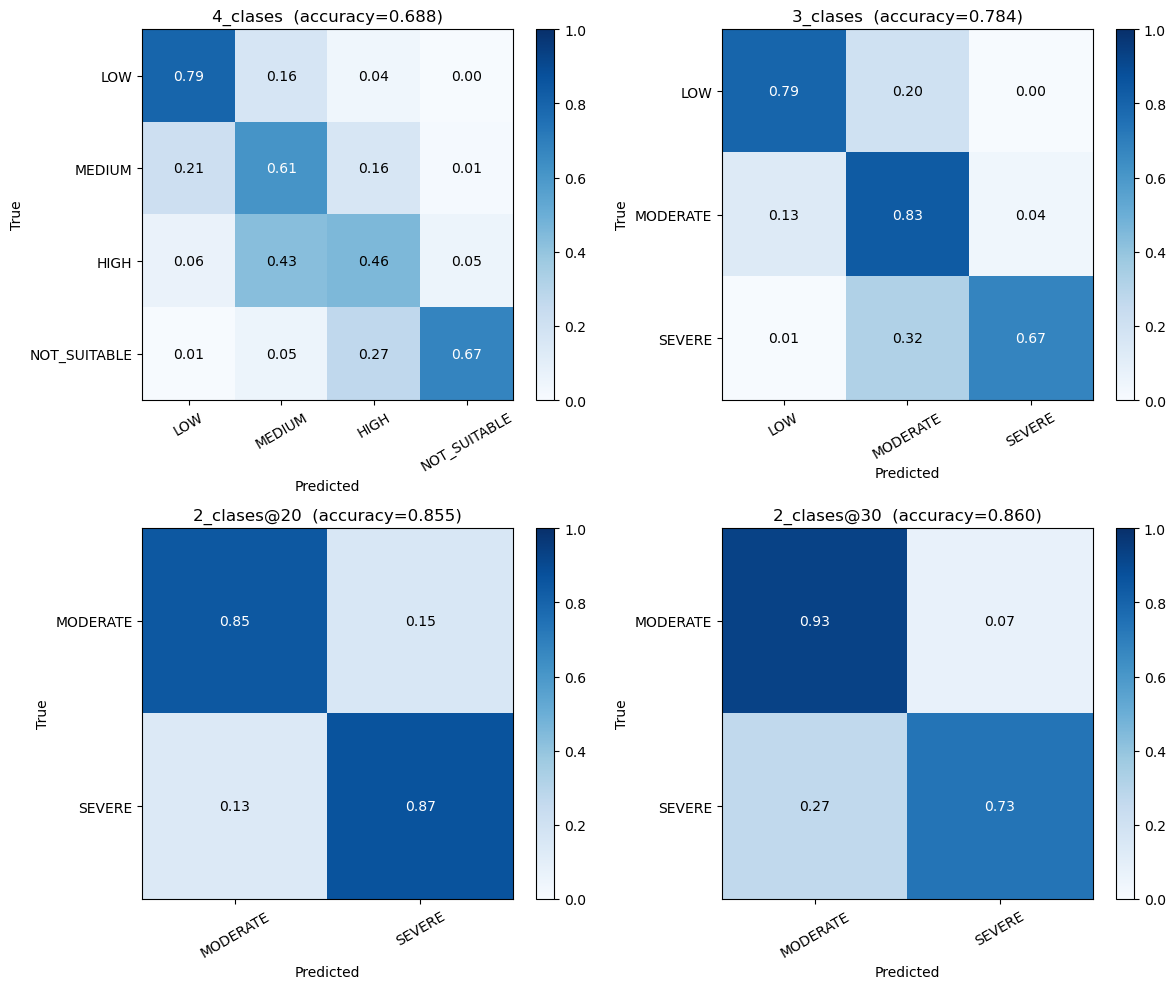

In [7]:
# -----------------------------------------------------------------------------
# Side-by-side normalized confusion matrices (one heatmap per scheme)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, (acc, recall, precision, cm_norm, names)) in zip(axes.ravel(), results.items()):
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=30)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{name}  (accuracy={acc:.3f})")
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()



## Summary

- The **regression accuracy is fixed** (MAE of the gated deficit does not change
  with binning). What changes is only the class scheme applied on top.
- **Fewer classes -> higher exact-class recall**, because each removed boundary
  removes the errors that crossed it. The biggest gain is merging MEDIUM + HIGH
  into MODERATE, which eliminates the dominant MEDIUM<->HIGH confusion.
- Because we chose **regression**, this re-binning is free: no retraining, just a
  different mapping of the same continuous predictions.

